# Processed Data Verification & EDA
This notebook verifies the integrity of the modular Parquet components and performs basic EDA on the engineered technical features.

In [11]:
%load_ext autoreload
%autoreload 2

import os
import sys
# import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.data.data_module import DataModule

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Load Modular Components via DataModule

In [12]:
PROCESSED_DIR = "../data/processed_market"
dm = DataModule(PROCESSED_DIR)

# Load and join features, targets, and metadata
df = dm.prepare_dataset(components=["technical_features", "targets", "metadata"])
df.sort_index(inplace=True)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset prepared successfully: 30032 rows.
Dataset loaded: 30032 rows, 46 columns


,real_volume,Ret_Open,Ret_High,Ret_Low,Ret_Close,Ret_Vol,TRIX_30_9,VWAP_D,ROC_10,RSI_14,...,Target_24h_1.0x_TBM,Target_24h_1.5x_TBM,Target_24h_2.0x_TBM,Target_24h_2.5x_TBM,Target_24h_3.0x_TBM,Open,High,Low,Close,Volume
time,,,,,,,,,,,,,,,,,,,,,
2021-06-01 00:00:00+00:00,0,0.000213,0.000163,0.000711,-0.000245,2.477032,0.001711,1.222937,0.013903,64.917432,...,0.0,0.0,2.0,2.0,2.0,1.22326,1.22346,1.22239,1.22296,984
2021-06-01 01:00:00+00:00,0,-0.000245,0.000564,0.000074,0.000188,0.746951,0.002072,1.223127,0.021260,66.324196,...,1.0,0.0,1.0,2.0,2.0,1.22296,1.22365,1.22287,1.22319,1719
2021-06-01 02:00:00+00:00,0,0.000188,0.000311,0.000441,-0.000302,-0.424666,0.002412,1.223097,0.000000,62.016031,...,0.0,0.0,0.0,2.0,2.0,1.22319,1.22357,1.22265,1.22282,989
2021-06-01 03:00:00+00:00,0,-0.000302,0.000327,0.000188,0.000164,-0.142568,0.002735,1.223068,0.021263,63.399963,...,0.0,0.0,2.0,2.0,2.0,1.22282,1.22322,1.22259,1.22302,848
2021-06-01 04:00:00+00:00,0,0.000164,0.000000,0.000638,-0.000638,0.161557,0.003022,1.222967,-0.042527,54.985743,...,0.0,0.0,0.0,0.0,2.0,1.22302,1.22302,1.22224,1.22224,985


In [13]:
for c in df.columns:
    if c.startswith("Target"):
        print(c)

Target_5h_1.0x_TBM
Target_5h_1.5x_TBM
Target_5h_2.0x_TBM
Target_5h_2.5x_TBM
Target_5h_3.0x_TBM
Target_12h_1.0x_TBM
Target_12h_1.5x_TBM
Target_12h_2.0x_TBM
Target_12h_2.5x_TBM
Target_12h_3.0x_TBM
Target_24h_1.0x_TBM
Target_24h_1.5x_TBM
Target_24h_2.0x_TBM
Target_24h_2.5x_TBM
Target_24h_3.0x_TBM


In [14]:
# Calculate class distribution for each target column
for col in df.columns:
    if col.startswith("Target"):
        print(f"\nDistribution for {col}:")
        counts = df[col].value_counts(normalize=True).sort_index()
        labels = ["Buy (0)", "Sell (1)", "Neutral (2)"]
        for i, val in enumerate(counts):
            print(f"  {labels[i]}: {val:.2%}")


Distribution for Target_5h_1.0x_TBM:
  Buy (0): 28.41%
  Sell (1): 29.04%
  Neutral (2): 42.55%

Distribution for Target_5h_1.5x_TBM:
  Buy (0): 17.65%
  Sell (1): 18.35%
  Neutral (2): 63.99%

Distribution for Target_5h_2.0x_TBM:
  Buy (0): 11.10%
  Sell (1): 11.81%
  Neutral (2): 77.08%

Distribution for Target_5h_2.5x_TBM:
  Buy (0): 7.17%
  Sell (1): 7.62%
  Neutral (2): 85.21%

Distribution for Target_5h_3.0x_TBM:
  Buy (0): 4.74%
  Sell (1): 5.05%
  Neutral (2): 90.21%

Distribution for Target_12h_1.0x_TBM:
  Buy (0): 43.34%
  Sell (1): 43.94%
  Neutral (2): 12.72%

Distribution for Target_12h_1.5x_TBM:
  Buy (0): 33.89%
  Sell (1): 35.18%
  Neutral (2): 30.93%

Distribution for Target_12h_2.0x_TBM:
  Buy (0): 25.50%
  Sell (1): 26.98%
  Neutral (2): 47.52%

Distribution for Target_12h_2.5x_TBM:
  Buy (0): 19.27%
  Sell (1): 20.55%
  Neutral (2): 60.19%

Distribution for Target_12h_3.0x_TBM:
  Buy (0): 14.47%
  Sell (1): 15.57%
  Neutral (2): 69.96%

Distribution for Target_24h_

### 2. Alignment & Integrity Sanity Checks

In [15]:
# 1. Check for missing values (there should be none after processing)
nan_counts = df.isna().sum().sum()
print(f"Total NaNs in dataset: {nan_counts}")

# 2. Check time continuity (hourly data)
time_diffs = df.index.to_series().diff().dt.total_seconds() / 3600
print(f"Max time gap: {time_diffs.max()} hours")
print(f"Average time gap (excluding weekends): {time_diffs[time_diffs < 48].mean():.2f} hours")

# 3. Target Distribution
target_col = "Target_5h_TBM"
if target_col in df.columns:
    print(f"\nDistribution for {target_col}:")
    counts = df[target_col].value_counts(normalize=True).sort_index()
    labels = ["Profit (0)", "Loss (1)", "Timeout (2)"]
    for i, val in enumerate(counts):
        print(f"  {labels[i]}: {val:.2%}")

Total NaNs in dataset: 0
Max time gap: 73.0 hours
Average time gap (excluding weekends): 1.00 hours


### 3. Visualizing Technical Indicators & Price

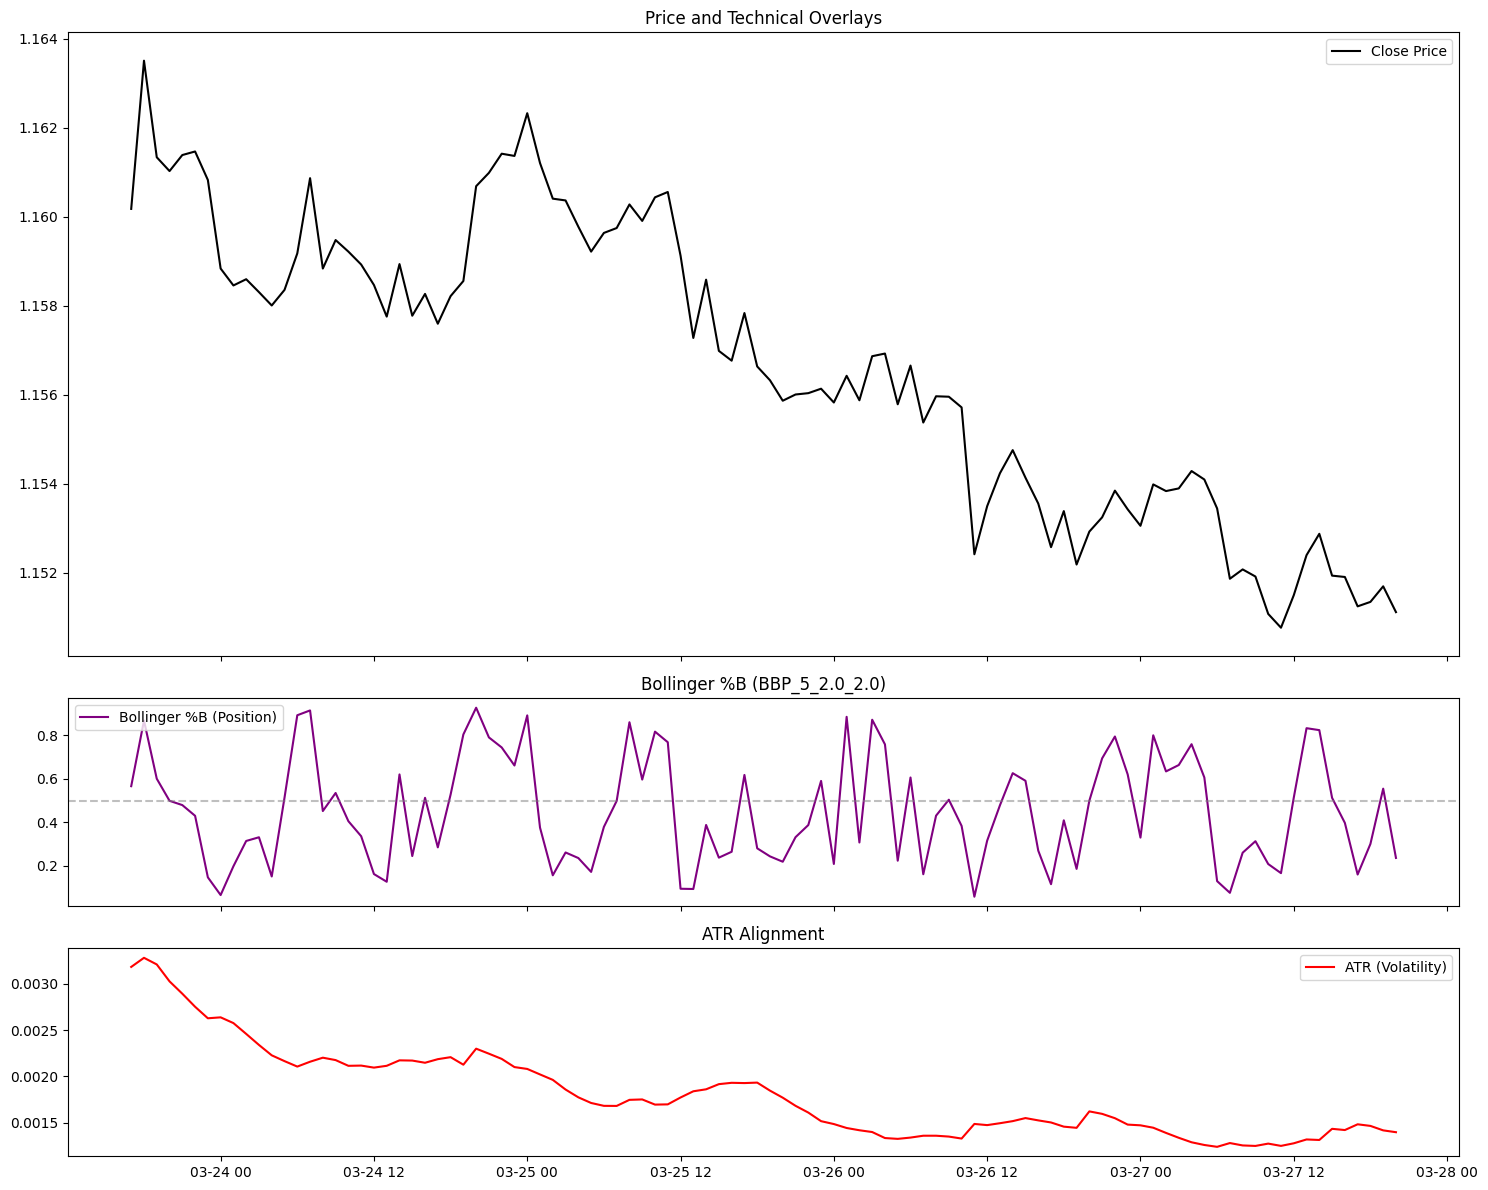

In [16]:
# Plot last 100 periods for visual confirmation of ATR and Bollinger Band features
plot_df = df.tail(100)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# Price Plot
ax1.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black')
ax1.set_title("Price and Technical Overlays")
ax1.legend()

# Bollinger %B (BBP) - Stationary relative position
bb_col = [c for c in df.columns if "BBP" in c][0] if any("BBP" in c for c in df.columns) else None
if bb_col:
    ax2.plot(plot_df.index, plot_df[bb_col], label='Bollinger %B (Position)', color='purple')
    ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
    ax2.set_title(f"Bollinger %B ({bb_col})")
    ax2.legend()

# ATR Plot
if 'ATRr_14' in df.columns:
    ax3.plot(plot_df.index, plot_df['ATRr_14'], label='ATR (Volatility)', color='red')
    ax3.set_title("ATR Alignment")
    ax3.legend()

plt.tight_layout()
plt.show()

### 4. Indicator Correlation Matrix

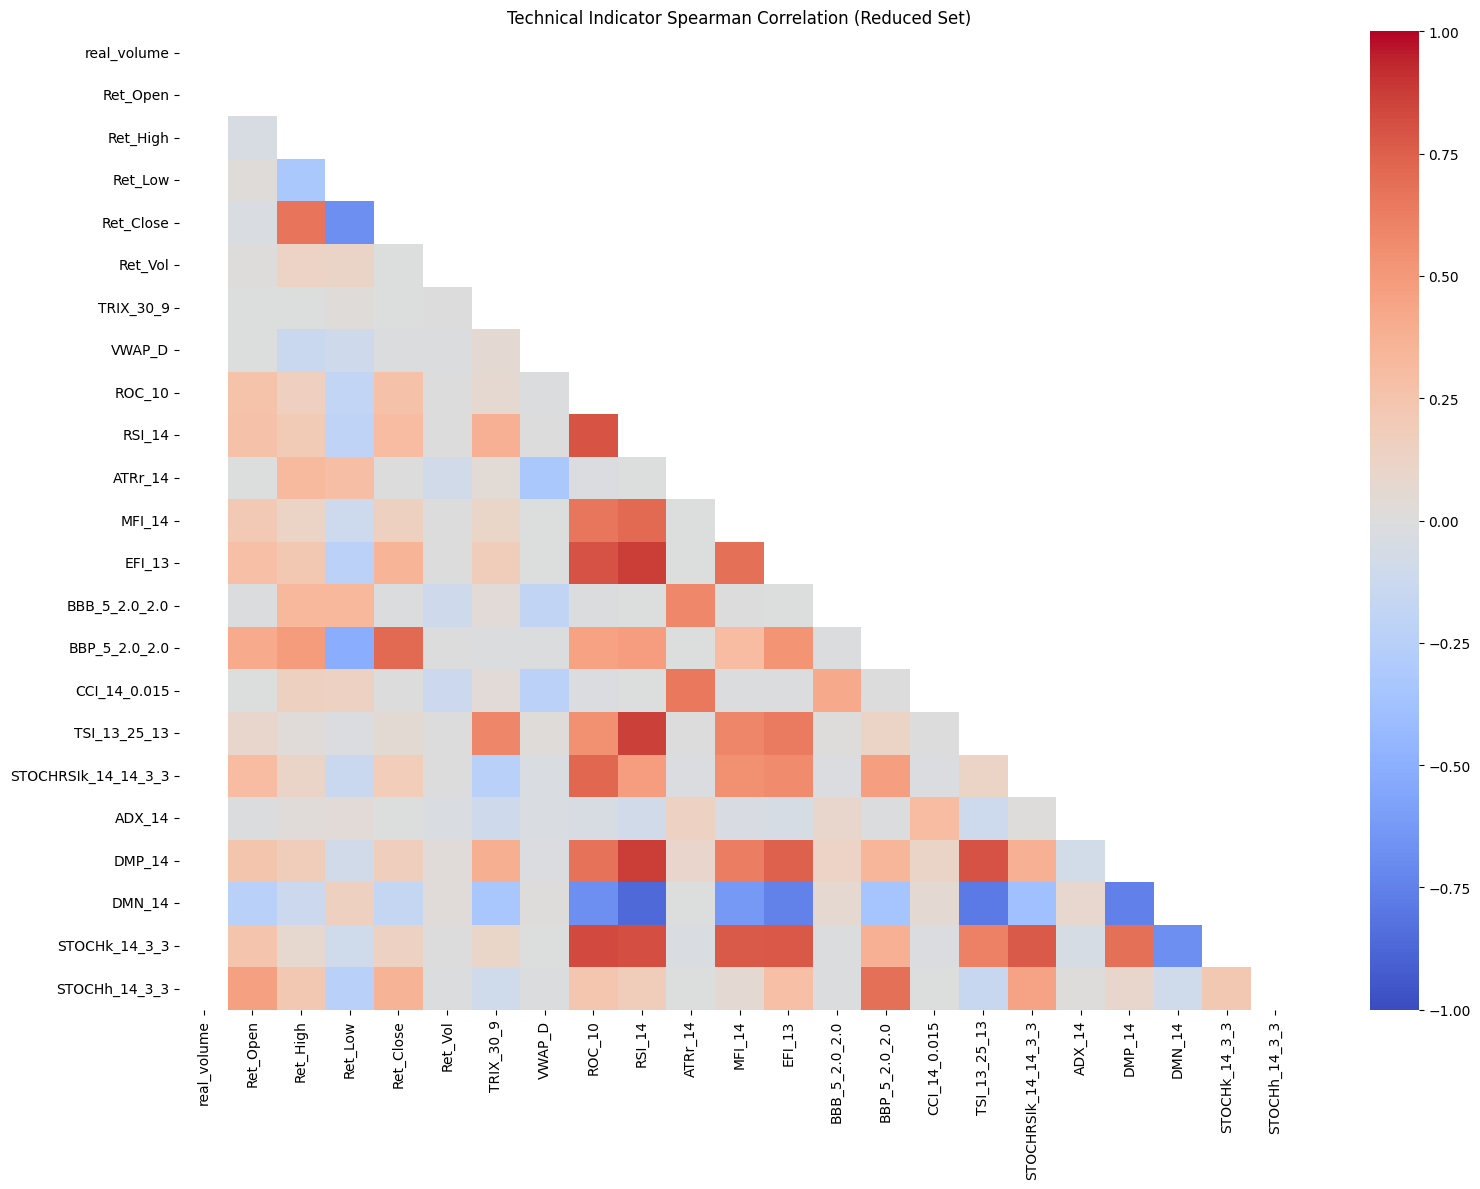

In [17]:
target_cols = [c for c in df.columns if "Target" in c or "LogRet" in c]
metadata_cols = ["Open", "High", "Low", "Close", "Volume"]
indicator_cols = [col for col in df.columns if col not in target_cols and col not in metadata_cols]

plt.figure(figsize=(16, 12))
corr_matrix = df[indicator_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Technical Indicator Spearman Correlation (Reduced Set)")
plt.tight_layout()
plt.show()